In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3049/FORS2.2022-01-16T07_25_38.100/NGC-3049_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3049/FORS2.2022-01-16T07_25_38.100/NGC-3049_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     387   (2094, 965)   float32   
  1  IMAGE.ERR     1 ImageHDU        68   (2094, 965)   float32   


In [3]:
image_cut = image[67:167, 0:1890]
image_error_cut = image_error[67:167, 0:1890]

Text(0.5, 0, 'wavelength')

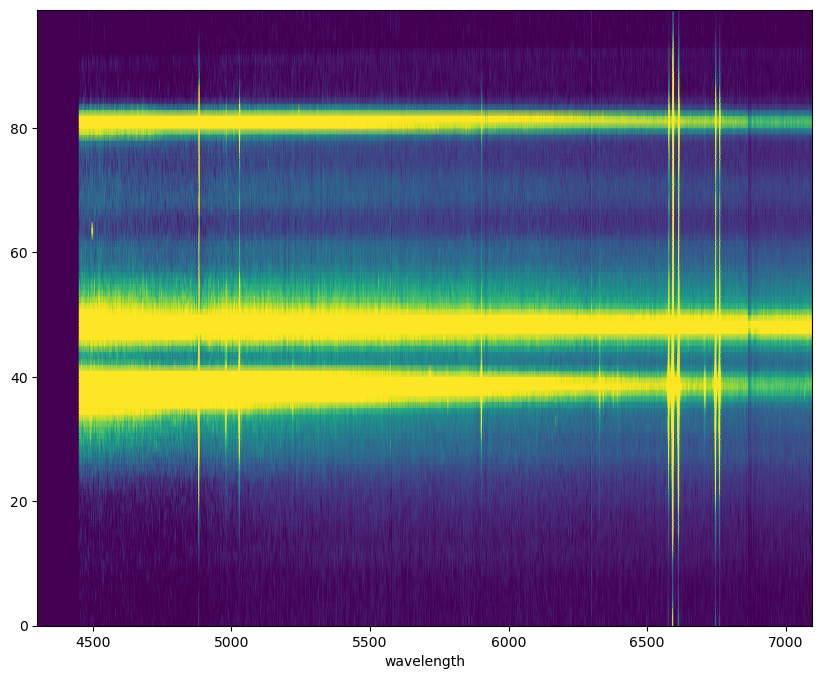

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [5]:
z = 0.00485
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = 1.984
sigma = seeing / 2.35
n_component = 3

In [6]:
l_HA

6594.830550000001

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3049/FORS2.2022-01-16T07_25_38.100/NGC-3049_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     387   (2094, 965)   float32   
  1  IMAGE.ERR     1 ImageHDU        68   (2094, 965)   float32   


Text(0.5, 0, 'wavelength')

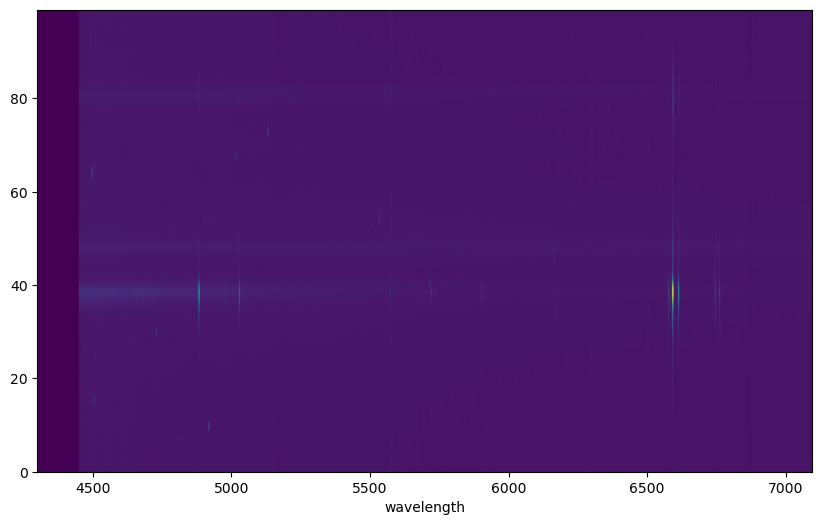

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3049/FORS2.2022-01-16T07_25_38.100/NGC-3049_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[67:167, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

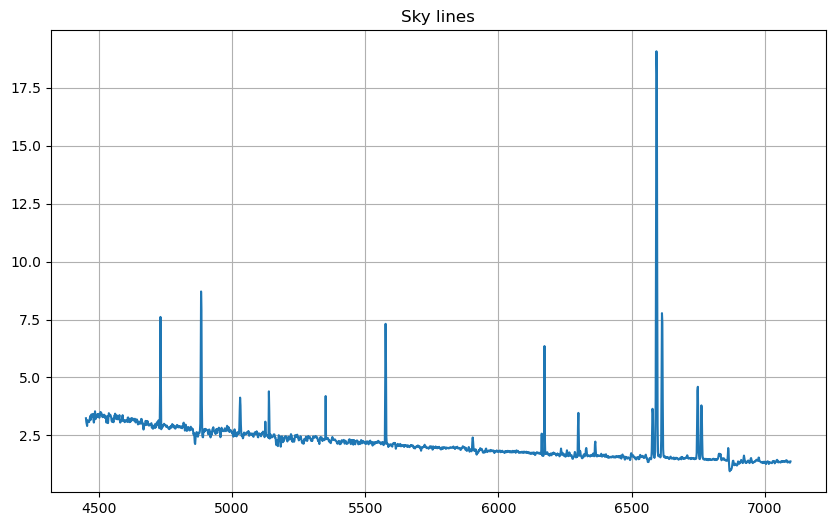

In [8]:
mask_sky = (y > 22)*(y < 32)
mask_wv = wv > 4450.5
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

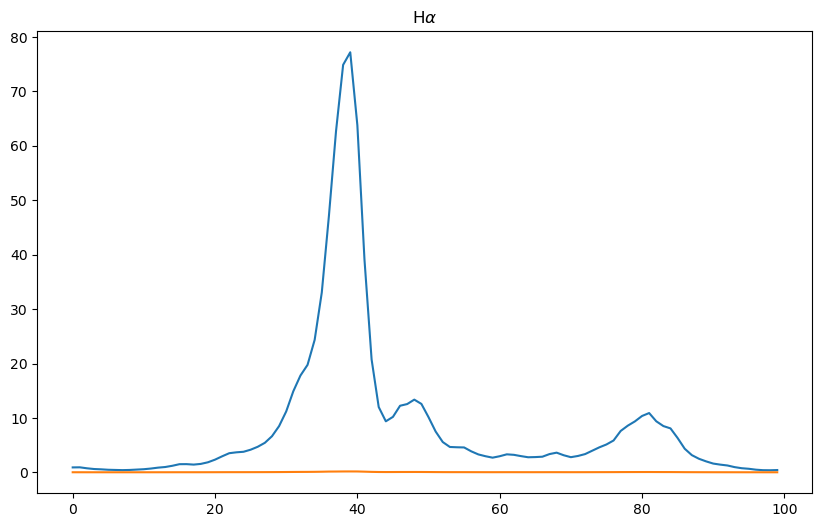

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [10]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) #+
        #sersic_1d(x_hr, *params[12:16]) +
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 85)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 85)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 5),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 40),   # x_0: posizione da 0 a 100

    (0, 5),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 5),
    (0, 50),
    (0.1, 10),
    (75, 85)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

In [15]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 4156.496936437461
differential_evolution step 2: f(x)= 4156.496936437461
differential_evolution step 3: f(x)= 4156.496936437461
differential_evolution step 4: f(x)= 2124.2485727812764
differential_evolution step 5: f(x)= 1677.9520018156488
differential_evolution step 6: f(x)= 1677.9520018156488
differential_evolution step 7: f(x)= 1677.9520018156488
differential_evolution step 8: f(x)= 1677.9520018156488
differential_evolution step 9: f(x)= 1677.9520018156488
differential_evolution step 10: f(x)= 1677.9520018156488
differential_evolution step 11: f(x)= 1677.9520018156488
differential_evolution step 12: f(x)= 1034.4520300210115
differential_evolution step 13: f(x)= 1034.4520300210115
differential_evolution step 14: f(x)= 1034.4520300210115
differential_evolution step 15: f(x)= 1034.4520300210115
differential_evolution step 16: f(x)= 1034.4520300210115
differential_evolution step 17: f(x)= 809.4719302775213
differential_evolution step 18: f(x)= 809.47

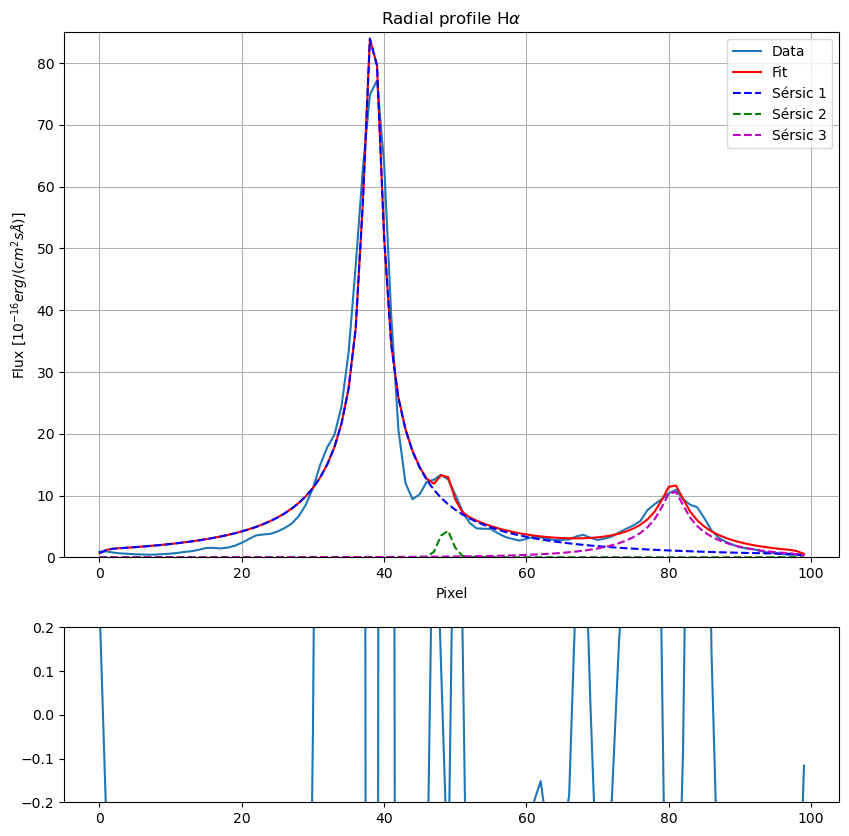

In [16]:
plot_diff(x_axes, best_params, radial_profile_HA, r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [19]:
bounds_HA = [
    (0.5, 1.5),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 5),  # n: da 0.1 a 10
    (35, 40),   # x_0: posizione da 0 a 100

    (0.5, 1.5),
    (0, 1),
    (0.1, 4),
    (45, 50),

    (0.5, 1.5),
    (0, 20),
    (0.1, 5),
    (80, 85)
]
lower_bounds, upper_bounds = zip(*bounds_HA)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA, bounds = bounds_list)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, radial_profile_error_HA,
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.0745, r_e=33.9201, n=3.0976, x_0=38.2614
Sérsic 2: I_e=1.1522, r_e=0.7845, n=2.3562, x_0=48.4974
Sérsic 3: I_e=1.3400, r_e=11.4632, n=1.3547, x_0=80.2973
[4.33029125e-01 9.25799002e+00 3.29025607e-01 8.36837210e-02
 8.19918530e+01 3.25770912e+01 2.39702827e+02 1.47054479e-01
 7.45485970e-01 4.40133604e+00 3.99384009e-01 3.60318097e-01]
887.3891058231267


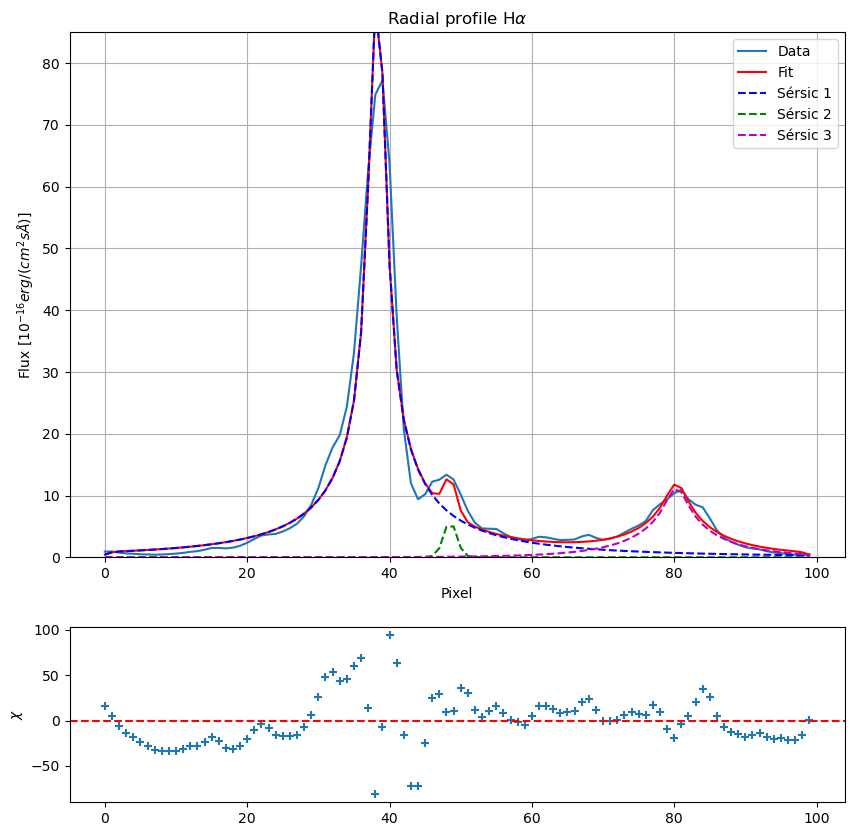

In [20]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [22]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-(seeing/2), x_0_HA[0]+(seeing/2)),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-(seeing/2), x_0_HA[1]+(seeing/2)),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-(seeing/2), x_0_HA[2]+(seeing/2))
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

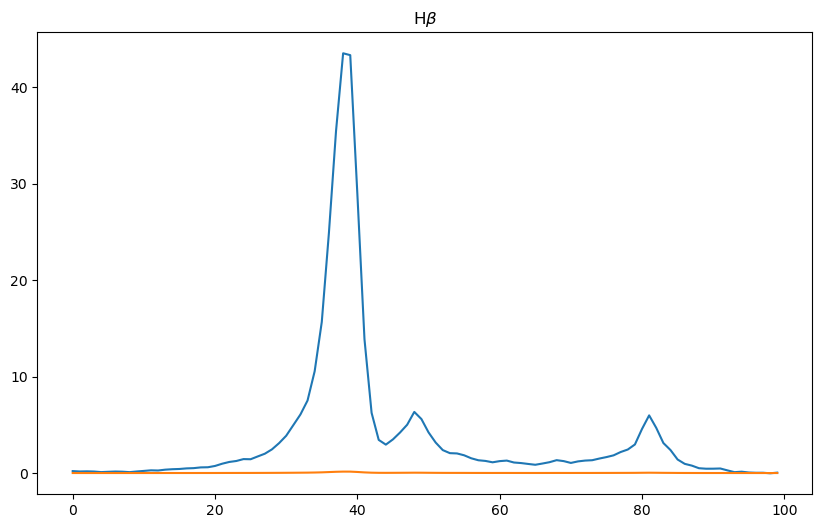

In [23]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [24]:
bounds

[(0, 1),
 (0, 50),
 (0.1, 10),
 (37.269400000000005, 39.2534),
 (0, 1),
 (0, 50),
 (0.1, 10),
 (47.5054, 49.489399999999996),
 (0, 1),
 (0, 50),
 (0.1, 10),
 (79.3053, 81.28930000000001)]

In [25]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 866.8612081626796
differential_evolution step 2: f(x)= 393.79264921954365
differential_evolution step 3: f(x)= 393.79264921954365
differential_evolution step 4: f(x)= 354.93576425745874
differential_evolution step 5: f(x)= 264.95703404525864
differential_evolution step 6: f(x)= 246.55533585251737
differential_evolution step 7: f(x)= 246.55533585251737
differential_evolution step 8: f(x)= 246.55533585251737
differential_evolution step 9: f(x)= 246.55533585251737
differential_evolution step 10: f(x)= 246.55533585251737
differential_evolution step 11: f(x)= 240.79293120264998
differential_evolution step 12: f(x)= 217.2958030353551
differential_evolution step 13: f(x)= 217.2958030353551
differential_evolution step 14: f(x)= 217.2958030353551
differential_evolution step 15: f(x)= 217.2958030353551
differential_evolution step 16: f(x)= 216.1122389528762
differential_evolution step 17: f(x)= 216.1122389528762
differential_evolution step 18: f(x)= 209.90032

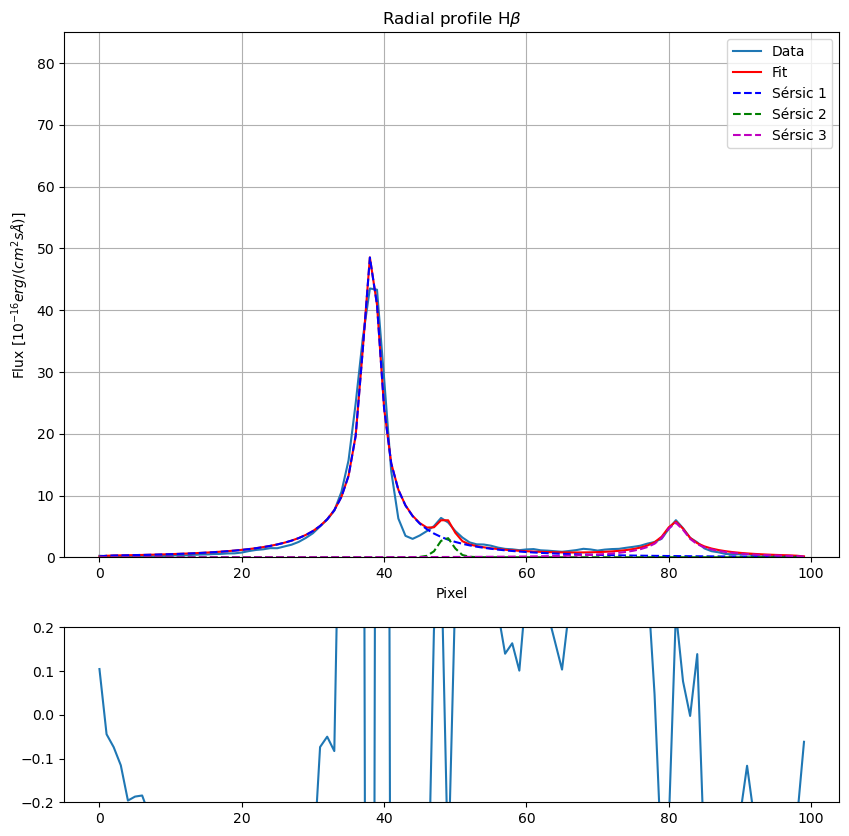

In [26]:
plot_diff(x_axes, best_params, radial_profile_HB, r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [33]:
bounds_new = [
    (0.5, 1.5),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 5),  # n: da 0.1 a 10
    (35, 40),   # x_0: posizione da 0 a 100

    (0.5, 1.5),
    (0, 3),
    (0.1, 4),
    (45, 50),

    (0, 1.5),
    (0, 25),
    (0.1, 5),
    (76, 85)
]
lower_bounds, upper_bounds = zip(*bounds_new)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB, bounds = bounds_list)

chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, radial_profile_error_HB,
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Sérsic 1: I_e=1.2925, r_e=14.4179, n=2.6548, x_0=38.0126
Sérsic 2: I_e=1.4953, r_e=1.7183, n=0.7846, x_0=48.8389
Sérsic 3: I_e=0.1670, r_e=23.7499, n=2.3238, x_0=80.8042
[4.97072232e-01 3.85632789e+00 3.12421007e-01 6.68814127e-02
 2.35395073e+00 1.34669651e+00 1.25995273e+00 3.48809421e-01
 4.77124225e-01 4.77255164e+01 2.55582660e+00 3.72958162e-02]
215.6685286932786


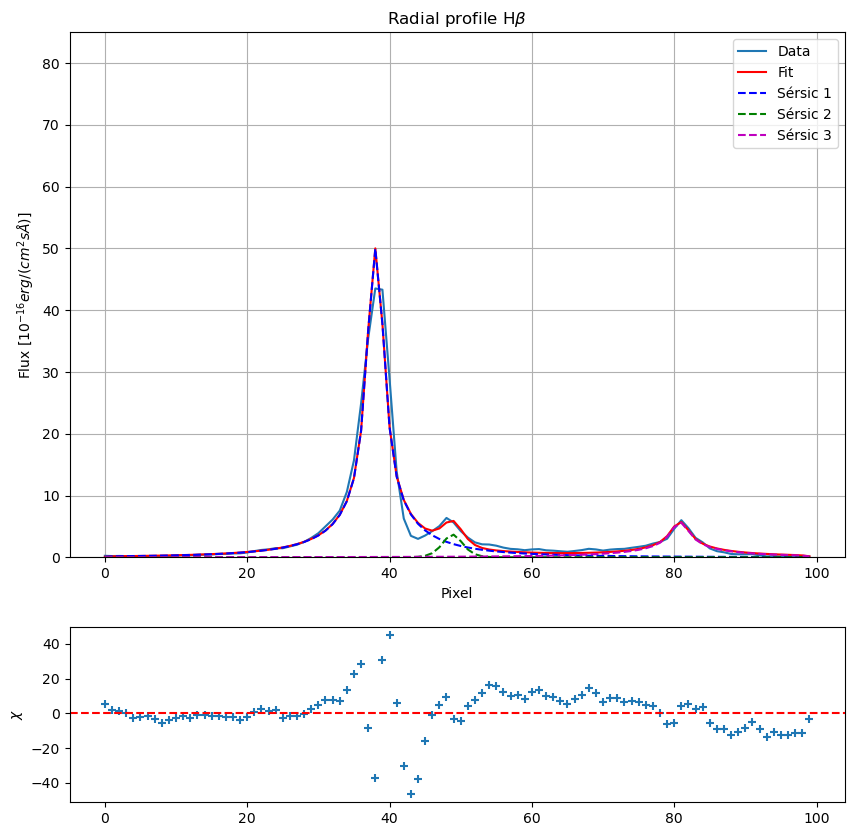

In [34]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

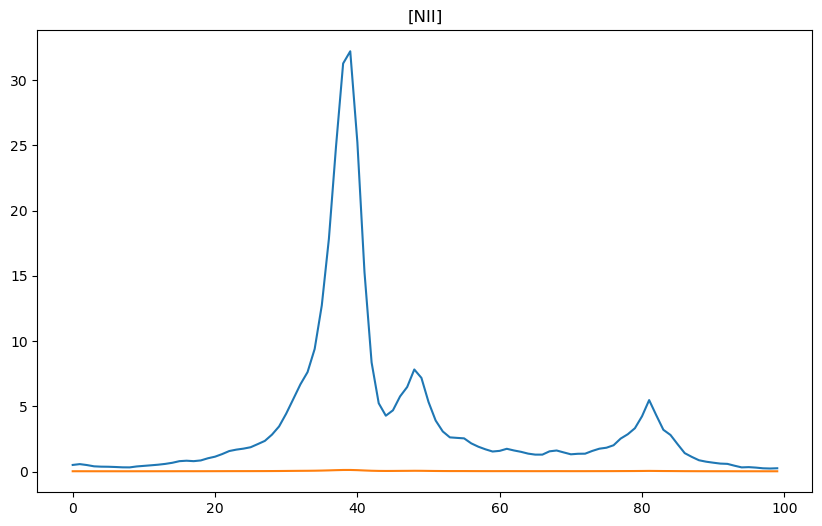

In [35]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [36]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 394.25566869314855
differential_evolution step 2: f(x)= 394.25566869314855
differential_evolution step 3: f(x)= 126.96167939783267
differential_evolution step 4: f(x)= 126.96167939783267
differential_evolution step 5: f(x)= 126.96167939783267
differential_evolution step 6: f(x)= 126.96167939783267
differential_evolution step 7: f(x)= 126.96167939783267
differential_evolution step 8: f(x)= 126.96167939783267
differential_evolution step 9: f(x)= 126.96167939783267
differential_evolution step 10: f(x)= 126.96167939783267
differential_evolution step 11: f(x)= 126.96167939783267
differential_evolution step 12: f(x)= 126.96167939783267
differential_evolution step 13: f(x)= 126.96167939783267
differential_evolution step 14: f(x)= 126.96167939783267
differential_evolution step 15: f(x)= 126.96167939783267
differential_evolution step 16: f(x)= 126.96167939783267
differential_evolution step 17: f(x)= 126.96167939783267
differential_evolution step 18: f(x)= 12

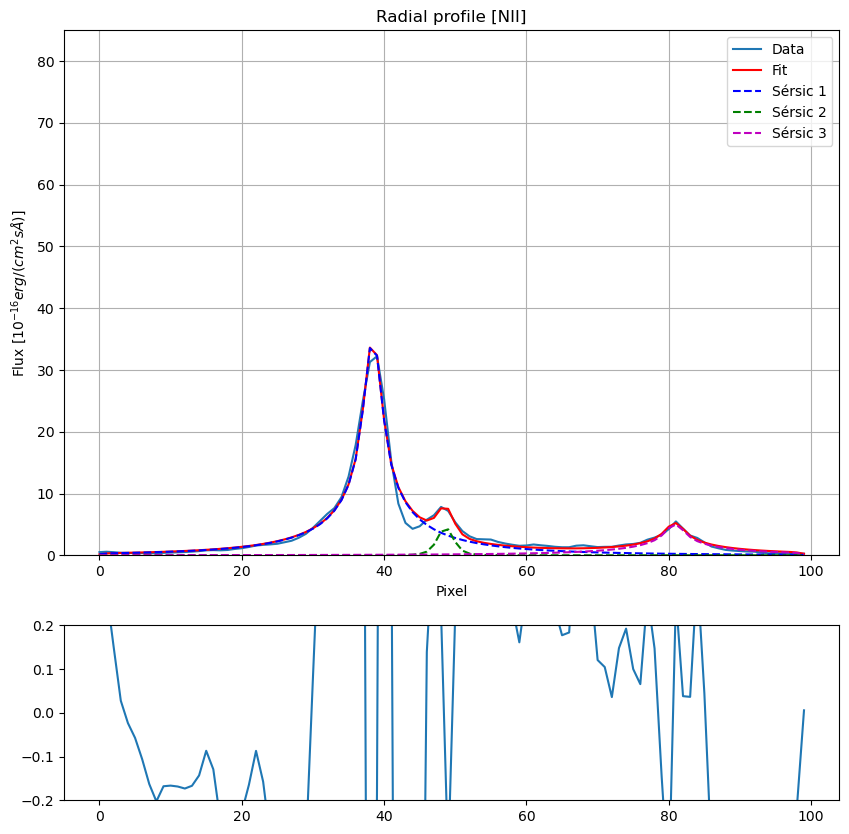

In [37]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII, r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [38]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII, bounds = bounds_list, maxfev=10000)

chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, radial_profile_error_NII,
    x_axes, n_component, line_name="NII", output_prefix="fit")

Sérsic 1: I_e=0.8266, r_e=23.0846, n=2.5635, x_0=38.2629
Sérsic 2: I_e=1.0000, r_e=2.2514, n=1.2991, x_0=48.6751
Sérsic 3: I_e=0.1527, r_e=30.6935, n=2.2383, x_0=80.7162
[ 0.22891639  4.56169577  0.21786508  0.07072592  1.63244269  2.13651219
  1.35152772  0.22223163  0.17594516 28.59172239  0.80110108  0.24590014]
201.0921588600794


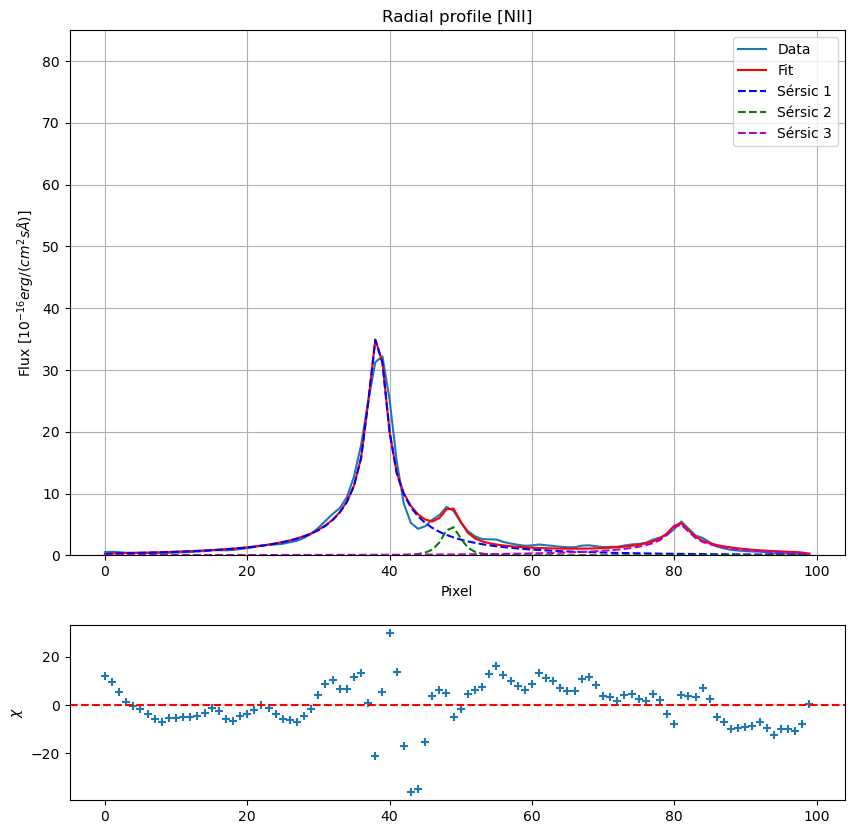

In [39]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

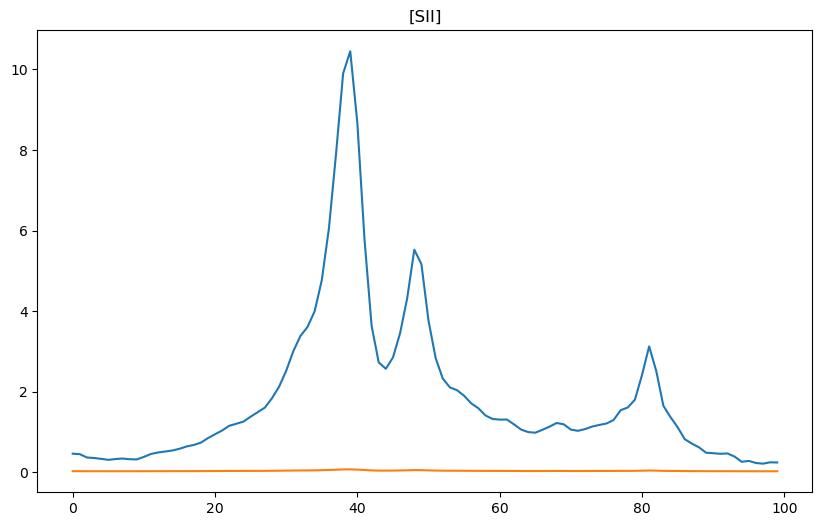

In [40]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [41]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 58.14056421131519
differential_evolution step 2: f(x)= 58.14056421131519
differential_evolution step 3: f(x)= 58.14056421131519
differential_evolution step 4: f(x)= 58.14056421131519
differential_evolution step 5: f(x)= 58.14056421131519
differential_evolution step 6: f(x)= 58.14056421131519
differential_evolution step 7: f(x)= 37.718168070078995
differential_evolution step 8: f(x)= 37.718168070078995
differential_evolution step 9: f(x)= 32.65552128884191
differential_evolution step 10: f(x)= 32.65552128884191
differential_evolution step 11: f(x)= 28.591162808394273
differential_evolution step 12: f(x)= 28.591162808394273
differential_evolution step 13: f(x)= 26.640685862422046
differential_evolution step 14: f(x)= 25.133563987969964
differential_evolution step 15: f(x)= 16.252883027064303
differential_evolution step 16: f(x)= 14.937871127700083
differential_evolution step 17: f(x)= 14.937871127700083
differential_evolution step 18: f(x)= 14.9378711

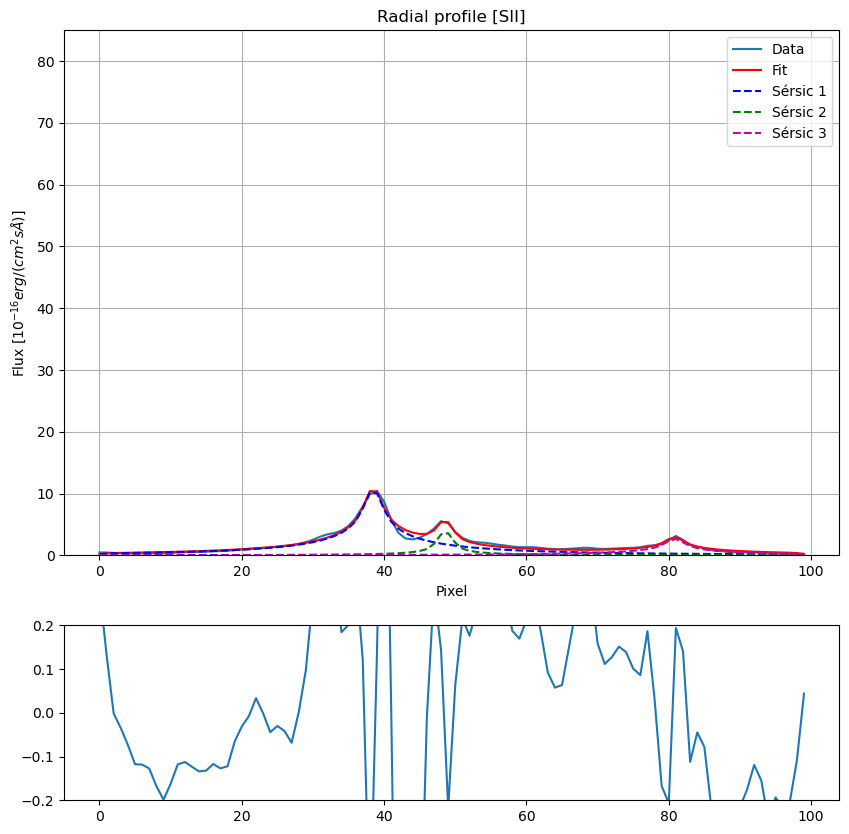

In [42]:
plot_diff(x_axes, best_params, radial_profile_SII, r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [43]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, radial_profile_error_SII,
    x_axes, n_component, line_name="SII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19040\2374069783.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19040\2374069783.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.1806, r_e=48.2428, n=2.6036, x_0=38.2901
Sérsic 2: I_e=0.0152, r_e=83.9809, n=3.8257, x_0=48.5964
Sérsic 3: I_e=0.0466, r_e=44.9196, n=2.6155, x_0=80.8281
[1.47407764e-01 3.99787572e+01 5.38002479e-01 9.57113392e-02
 2.08185057e-01 9.32248817e+02 1.09168891e+01 5.26471468e-04
 1.01497377e-01 8.86926877e+01 1.52760122e+00 2.03767589e-01]
66.57459767711647


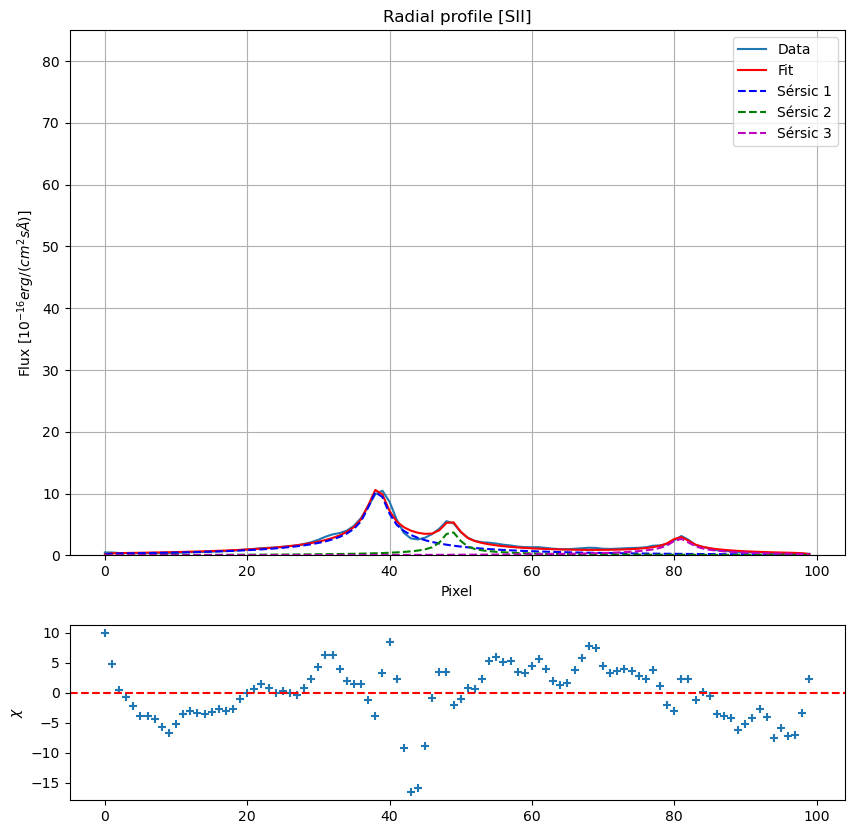

In [44]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

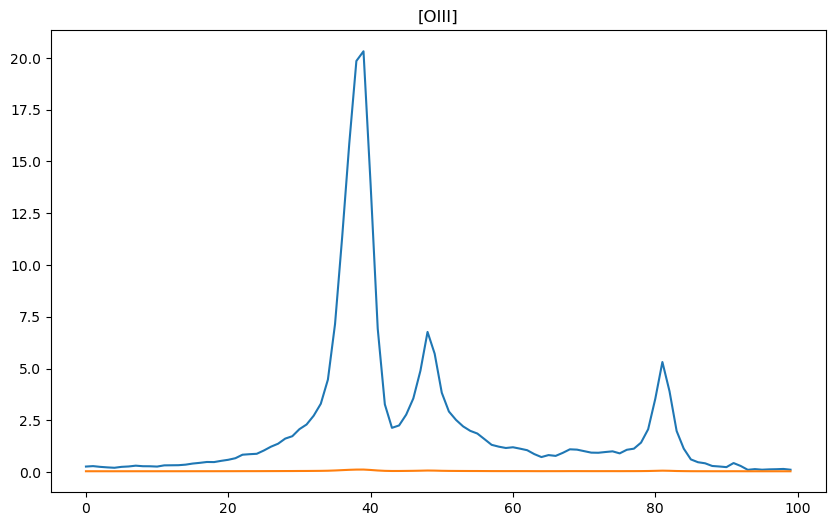

In [45]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [46]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 329.03232531550736
differential_evolution step 2: f(x)= 255.75862538277636
differential_evolution step 3: f(x)= 161.90285532692022
differential_evolution step 4: f(x)= 155.77546459235606
differential_evolution step 5: f(x)= 141.70309857180555
differential_evolution step 6: f(x)= 104.84912451761686
differential_evolution step 7: f(x)= 104.84912451761686
differential_evolution step 8: f(x)= 104.84912451761686
differential_evolution step 9: f(x)= 104.84912451761686
differential_evolution step 10: f(x)= 104.84912451761686
differential_evolution step 11: f(x)= 104.84912451761686
differential_evolution step 12: f(x)= 104.84912451761686
differential_evolution step 13: f(x)= 104.84912451761686
differential_evolution step 14: f(x)= 78.00636509883418
differential_evolution step 15: f(x)= 73.62104135553186
differential_evolution step 16: f(x)= 73.62104135553186
differential_evolution step 17: f(x)= 73.62104135553186
differential_evolution step 18: f(x)= 57.800

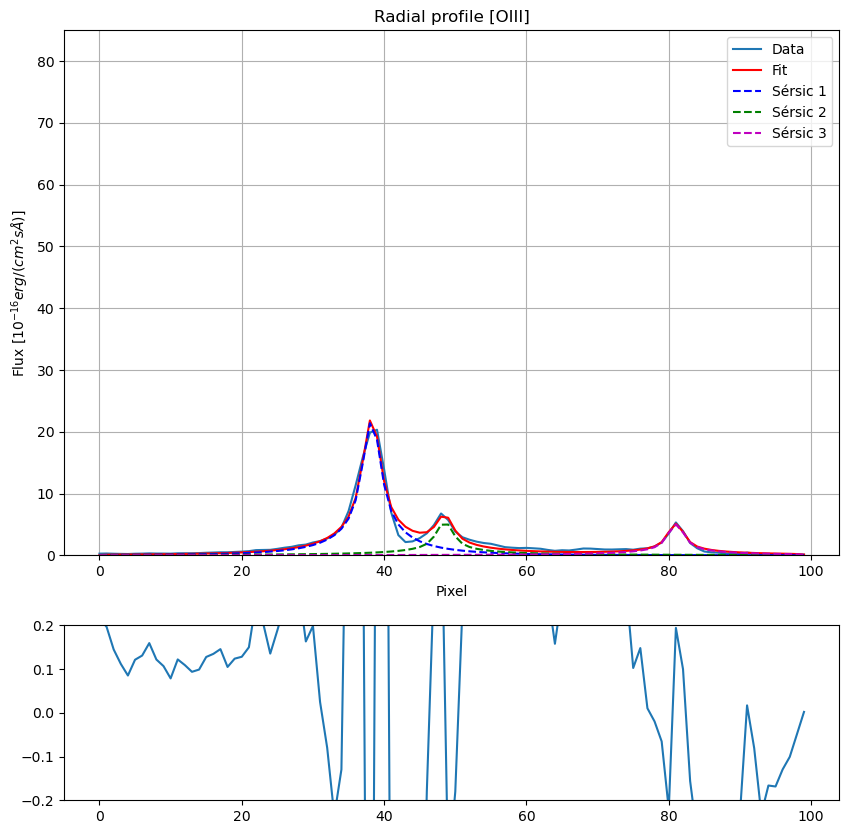

In [47]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII, r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [48]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, radial_profile_error_OIII,
    x_axes, n_component, line_name="OIII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19040\2374069783.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19040\2374069783.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=6.2864, r_e=2.6428, n=0.8743, x_0=38.0026
Sérsic 2: I_e=0.0039, r_e=1277.9777, n=4.6600, x_0=48.4974
Sérsic 3: I_e=0.3853, r_e=3.7544, n=2.0991, x_0=81.0018
[9.55969764e-01 2.13329373e-01 1.20700341e-01 6.32093485e-02
 1.65452471e-02 4.48356560e+03 3.14796777e+00 3.10027014e-04
 6.55319883e-01 4.00797369e+00 1.57474941e+00 1.31444447e-01]
78.58644496949054


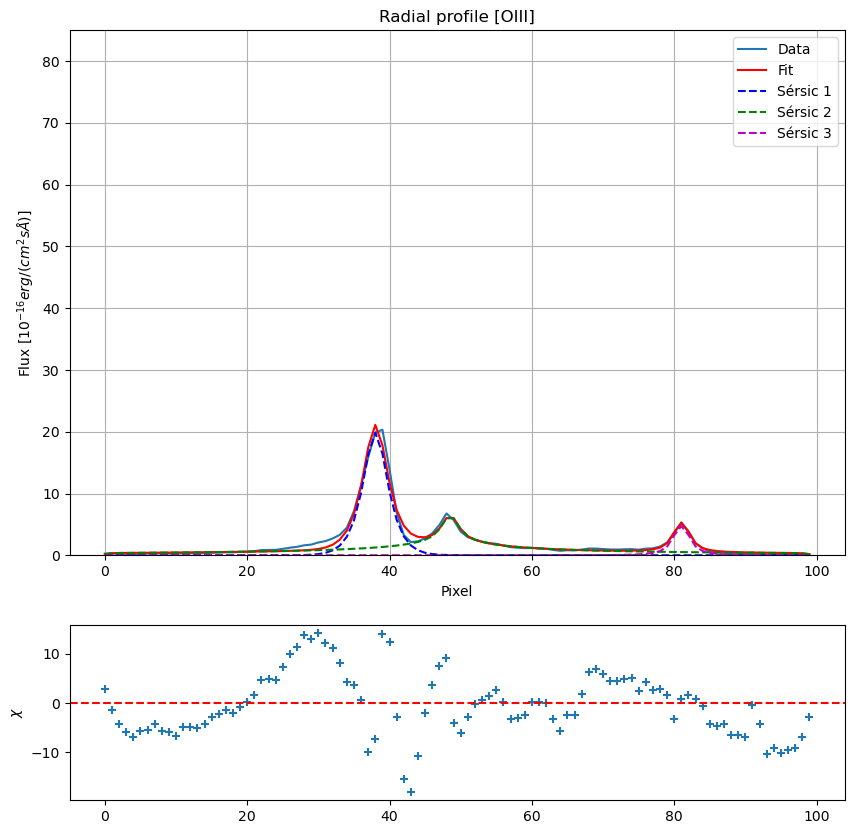

In [49]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

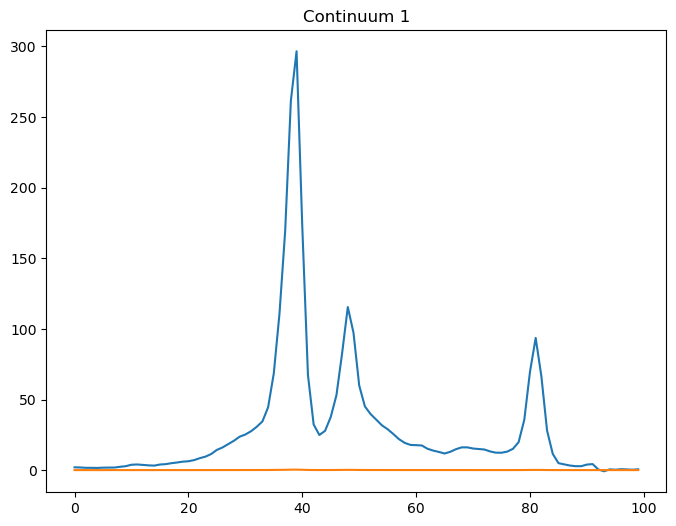

In [50]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [51]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 53914.64009047337
differential_evolution step 2: f(x)= 48395.99412989204
differential_evolution step 3: f(x)= 42340.407762573646
differential_evolution step 4: f(x)= 40685.54851246917
differential_evolution step 5: f(x)= 38476.201436821866
differential_evolution step 6: f(x)= 37800.31790269893
differential_evolution step 7: f(x)= 31150.465723474234
differential_evolution step 8: f(x)= 31150.465723474234
differential_evolution step 9: f(x)= 31150.465723474234
differential_evolution step 10: f(x)= 30295.734635378492
differential_evolution step 11: f(x)= 30295.734635378492
differential_evolution step 12: f(x)= 27090.058457347623
differential_evolution step 13: f(x)= 27090.058457347623
differential_evolution step 14: f(x)= 27090.058457347623
differential_evolution step 15: f(x)= 27090.058457347623
differential_evolution step 16: f(x)= 27090.058457347623
differential_evolution step 17: f(x)= 27090.058457347623
differential_evolution step 18: f(x)= 27090.

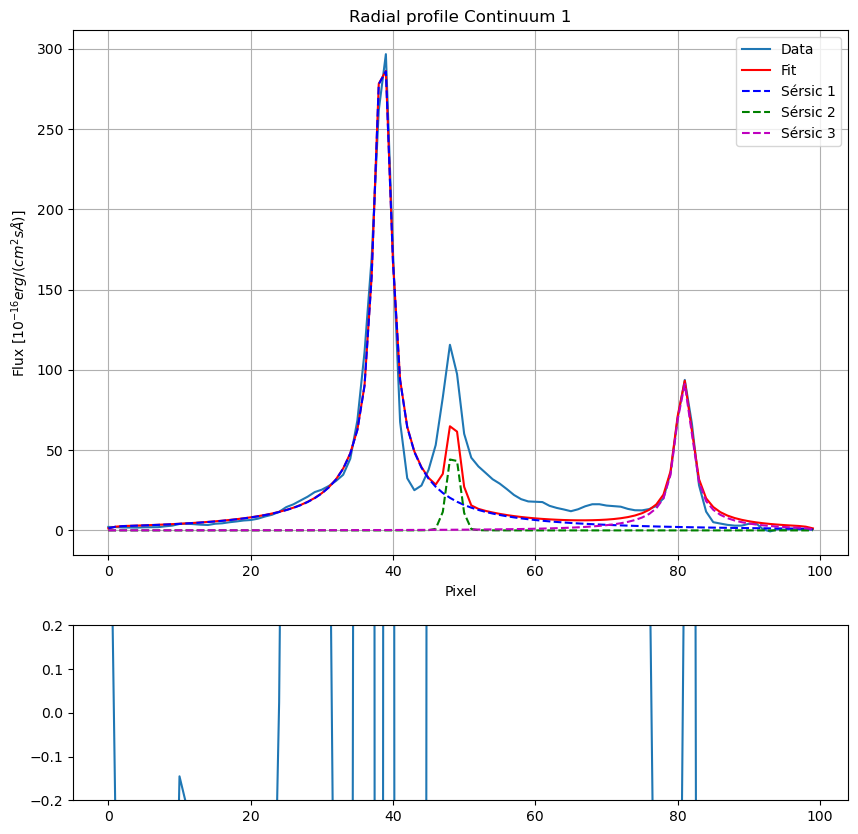

In [52]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 1450)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 1450)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_1, r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [53]:
params_curve_continuum_1, covariance_continuum_1 = curve_fit(model_convolved, x_axes, radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1)

chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, radial_profile_continuum_1, radial_profile_error_continuum_1,
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Sérsic 1: I_e=0.7233, r_e=59.5284, n=4.7139, x_0=38.3919
Sérsic 2: I_e=1.1041, r_e=38.1383, n=3.0601, x_0=48.4726
Sérsic 3: I_e=0.3762, r_e=35.7897, n=4.2555, x_0=80.8785
[2.09914920e+00 1.33345330e+02 2.22743126e+00 5.74781318e-02
 5.94462681e+00 1.60357151e+02 4.46121002e+00 4.81978703e-03
 4.62999195e+00 2.94548449e+02 1.26750546e+01 4.73267602e-04]
891.4065101937177


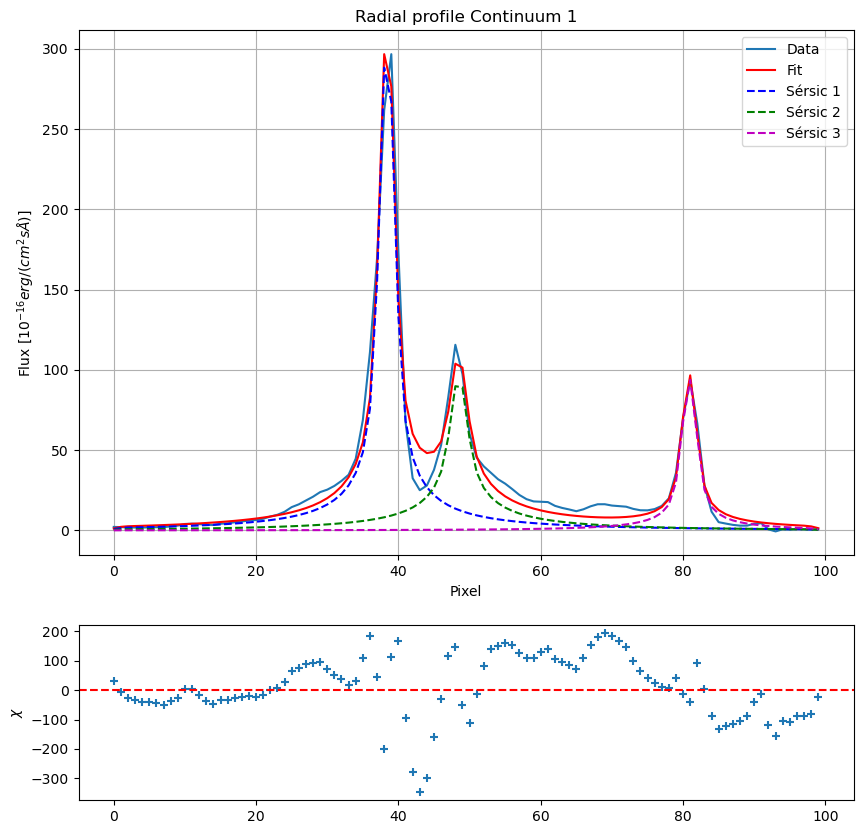

In [54]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

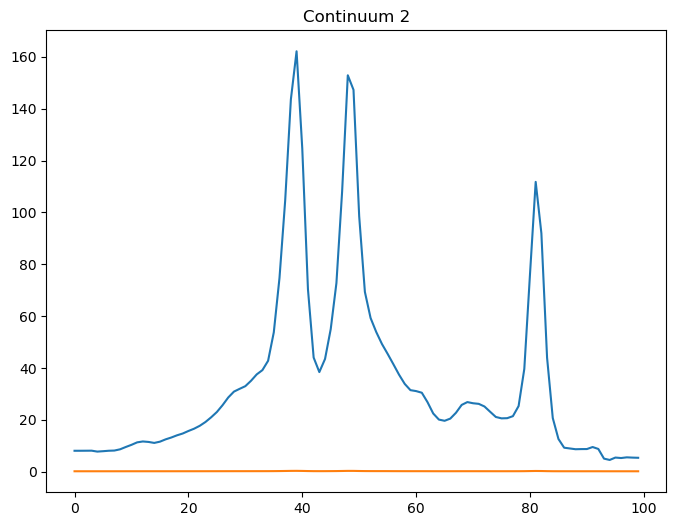

In [55]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [56]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 88901.6406574064
differential_evolution step 2: f(x)= 88901.6406574064
differential_evolution step 3: f(x)= 81771.7447632589
differential_evolution step 4: f(x)= 81771.7447632589
differential_evolution step 5: f(x)= 81771.7447632589
differential_evolution step 6: f(x)= 79844.25109004199
differential_evolution step 7: f(x)= 79844.25109004199
differential_evolution step 8: f(x)= 79844.25109004199
differential_evolution step 9: f(x)= 77359.65251476236
differential_evolution step 10: f(x)= 75935.67094510411
differential_evolution step 11: f(x)= 75935.67094510411
differential_evolution step 12: f(x)= 75367.69080318762
differential_evolution step 13: f(x)= 75367.69080318762
differential_evolution step 14: f(x)= 71005.26961348492
differential_evolution step 15: f(x)= 71005.26961348492
differential_evolution step 16: f(x)= 71005.26961348492
differential_evolution step 17: f(x)= 71005.26961348492
differential_evolution step 18: f(x)= 71005.26961348492
differ

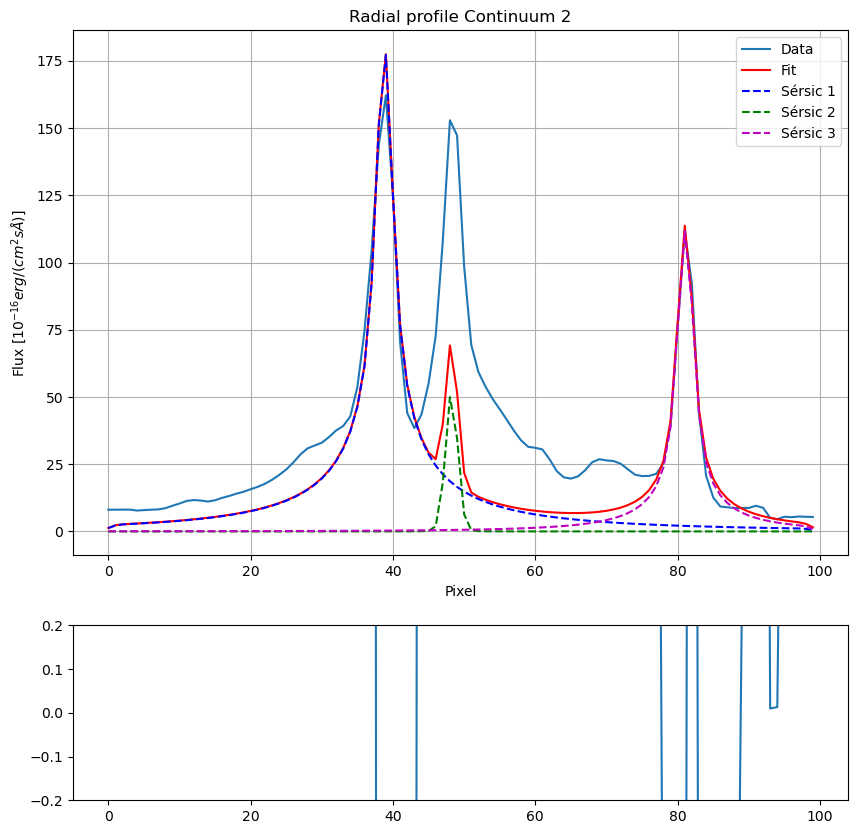

In [57]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, )
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, )
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
plot_diff(x_axes, best_params, radial_profile_continuum_2, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [58]:
params_curve_continuum_2, covariance_continuum_2 = curve_fit(model_convolved, x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2)#, maxfev=15000)
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
    radial_profile_error_continuum_2, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Sérsic 1: I_e=1.1786, r_e=113.4704, n=2.8890, x_0=38.2248
Sérsic 2: I_e=2.2460, r_e=21.2039, n=2.8887, x_0=48.2251
Sérsic 3: I_e=0.9485, r_e=26.2626, n=3.4954, x_0=81.0763
[1.48406487e+00 1.24789223e+02 8.91346422e-01 1.97977752e-01
 1.12020292e+01 7.76258666e+01 4.60673557e+00 8.82374575e-03
 6.08992958e+00 1.15983468e+02 6.44639615e+00 5.61425597e-02]
1701.8556147710055


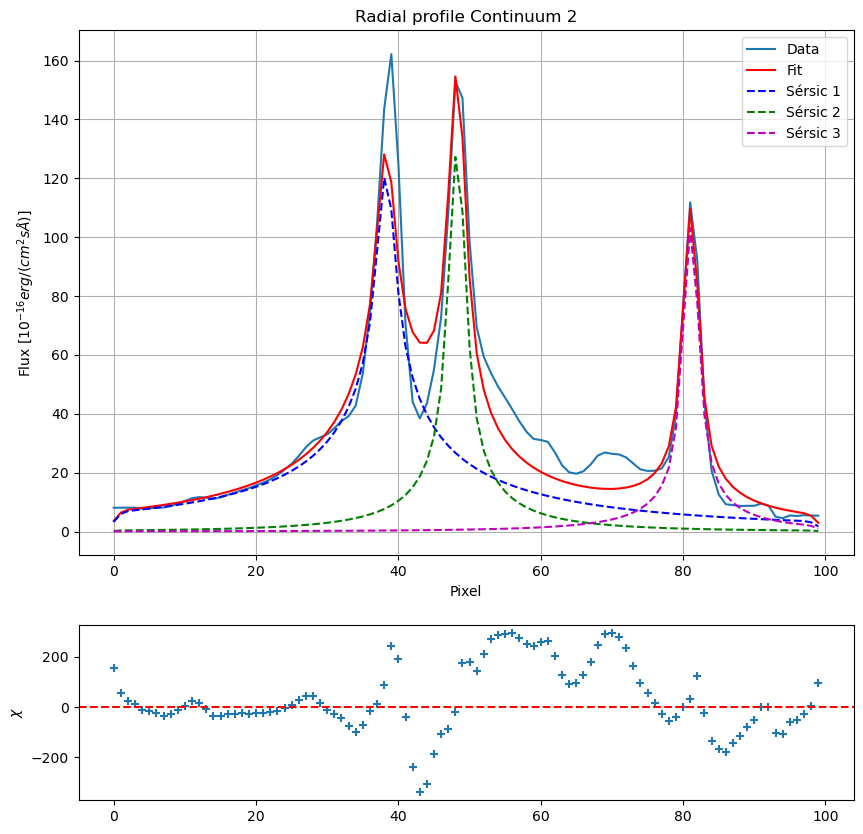

In [59]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

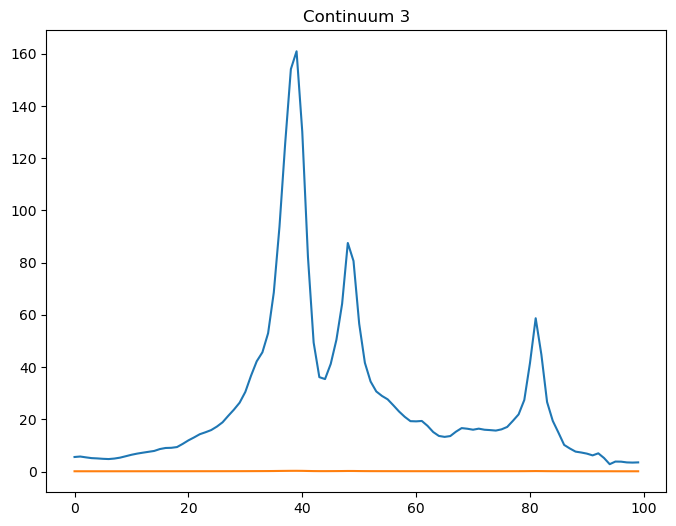

In [60]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [61]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 33402.93973712872
differential_evolution step 2: f(x)= 28545.385912633676
differential_evolution step 3: f(x)= 28545.385912633676
differential_evolution step 4: f(x)= 26163.616221677672
differential_evolution step 5: f(x)= 26163.616221677672
differential_evolution step 6: f(x)= 26163.616221677672
differential_evolution step 7: f(x)= 25977.452078922073
differential_evolution step 8: f(x)= 24525.150810669365
differential_evolution step 9: f(x)= 22875.93679189695
differential_evolution step 10: f(x)= 21879.329370542502
differential_evolution step 11: f(x)= 21879.329370542502
differential_evolution step 12: f(x)= 21879.329370542502
differential_evolution step 13: f(x)= 21328.095986242046
differential_evolution step 14: f(x)= 21328.095986242046
differential_evolution step 15: f(x)= 20651.069696993538
differential_evolution step 16: f(x)= 20597.517906335182
differential_evolution step 17: f(x)= 19957.949513696305
differential_evolution step 18: f(x)= 1995

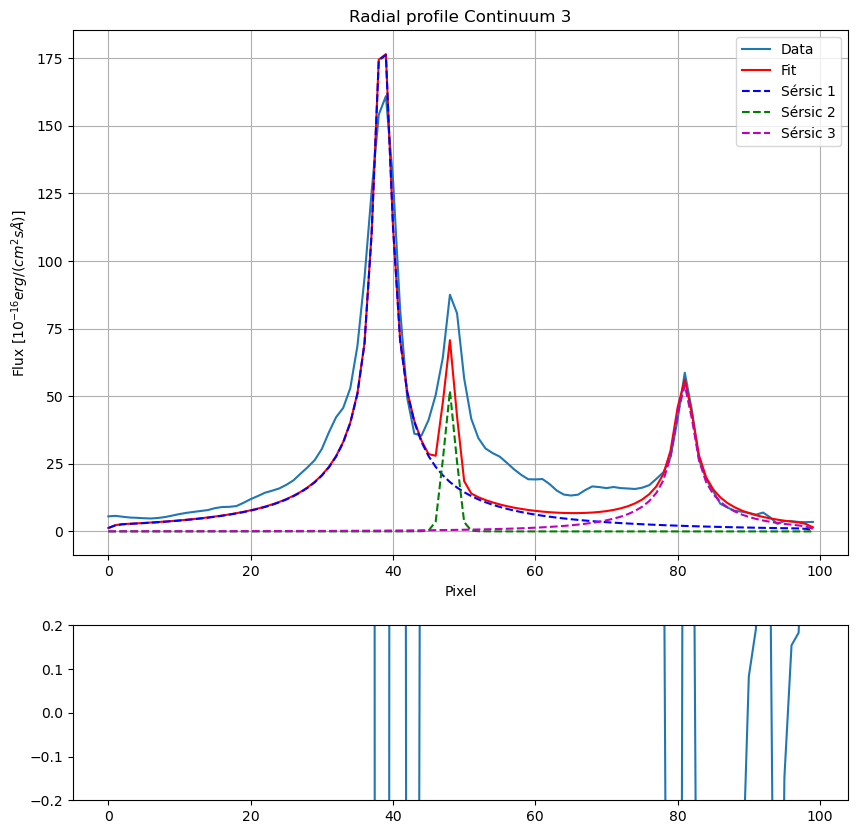

In [62]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_3, r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [63]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(model_convolved, x_axes, radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)

chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
    radial_profile_error_continuum_3, x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

Sérsic 1: I_e=0.8171, r_e=101.8131, n=3.5814, x_0=38.2791
Sérsic 2: I_e=0.8631, r_e=33.4293, n=2.9047, x_0=47.9775
Sérsic 3: I_e=0.2819, r_e=71.6871, n=3.5597, x_0=80.9284
[9.33118150e-01 1.04649756e+02 8.02733513e-01 8.13931553e-02
 5.04374899e+00 1.54275392e+02 4.91807037e+00 6.60401958e-03
 1.47424649e+00 2.88290520e+02 4.35725086e+00 1.03663017e-01]
1121.761175962111


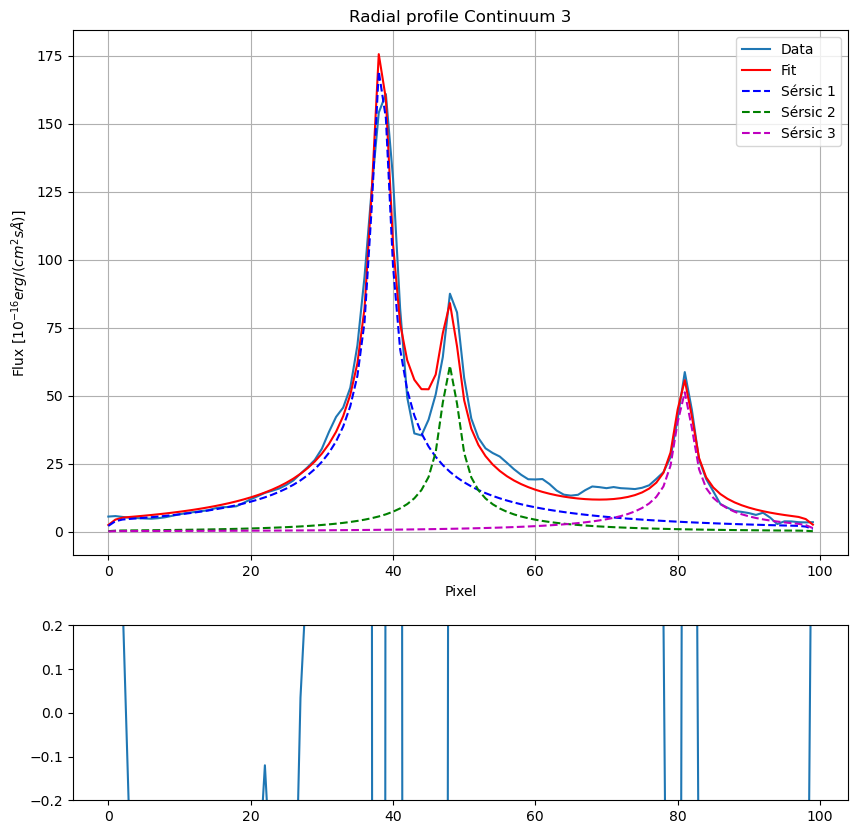

In [64]:
plot_diff(x_axes, params_curve_continuum_3, radial_profile_continuum_3, r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [65]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [66]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
